# **Compare models performance 📊**

## **Definitions**

- true positives (TP) = number of entities of the ground truth found by the model
- false positives (FP) = number of entities not in the ground truth found by the model
- false negatives (FN) = number of entities of the ground truth not found by the model

$$
{\rm precision} = \frac{TP}{TP + FP}
$$

$$
{\rm recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \frac{ {\rm precision} \times {\rm recall} }{ {\rm precision}+{\rm recall} } = \frac{ 2 TP }{ 2TP + FP + FN }
$$


$$
F_{\beta} = \frac{ (1 + \beta^2) \times {\rm precision} \times {\rm recall} }{ (\beta^2 \times {\rm precision}) + {\rm recall} } = \frac{ (1 + \beta^2) \times TP }{ \beta^2 \times (TP + FN) + TP + FP }
$$

In the case of Named Entity Recognition, we focus more on precision than recall. We want the model to make no mistakes rather that identify all entities.

## **Setup**

In [87]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd

from mdner_llm.core.plot_evaluation_metrics import (
    plot_llm_cost_vs_time,
    plot_mean_model_performance,
    plot_score,
)

pd.__version__

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

## **Comparison of LLM Models**

In [88]:
# LLMs evaluation results
path = Path("../results/llm/evaluation_stats_gemma/grouped_evaluation_metrics.csv")
llm_df = pd.read_csv(path)
model_names = llm_df["model_name"].unique()
framework_names = llm_df["framework_name"].unique()
category_names = llm_df["category"].unique()
print(f"Models ({len(model_names)}): {', '.join(model_names)}")
print(f"Frameworks ({len(framework_names)}): {', '.join(framework_names)}")
print(f"Categories ({len(category_names)}): {', '.join(category_names)}")
llm_df

Models (10): google/gemma-4-31b-it_run1, google/gemma-4-31b-it_run10, google/gemma-4-31b-it_run2, google/gemma-4-31b-it_run3, google/gemma-4-31b-it_run4, google/gemma-4-31b-it_run5, google/gemma-4-31b-it_run6, google/gemma-4-31b-it_run7, google/gemma-4-31b-it_run8, google/gemma-4-31b-it_run9
Frameworks (1): instructor
Categories (7): FFM, MOL, SOFTNAME, SOFTVERS, STEMP, STIME, OVERALL


,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,google/gemma-4-31b-it_run1,instructor,FFM,80,173,150,91.250000,13.750000,141,9,32,4418.424658,265.246575,NaN,NaN,0.940000,0.815029,0.873065,0.912031
1,google/gemma-4-31b-it_run1,instructor,MOL,107,560,445,90.654206,13.084112,355,90,205,4460.845361,269.793814,NaN,NaN,0.797753,0.633929,0.706468,0.758547
2,google/gemma-4-31b-it_run1,instructor,SOFTNAME,71,122,113,90.277778,13.888889,103,10,19,4428.200000,280.969231,NaN,NaN,0.911504,0.844262,0.876596,0.897213
3,google/gemma-4-31b-it_run1,instructor,SOFTVERS,44,50,49,91.304348,13.043478,42,7,8,4440.976190,287.071429,NaN,NaN,0.857143,0.840000,0.848485,0.853659
4,google/gemma-4-31b-it_run1,instructor,STEMP,49,77,75,88.679245,13.207547,66,9,11,4585.872340,309.723404,NaN,NaN,0.880000,0.857143,0.868421,0.875332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,google/gemma-4-31b-it_run5,instructor,OVERALL,112,1076,934,92.857143,9.821429,802,132,274,4397.576923,259.759615,0.068094,1619.834289,0.858672,0.745353,0.798010,0.833333
66,google/gemma-4-31b-it_run6,instructor,OVERALL,112,1076,924,90.178571,12.500000,781,143,295,4518.663366,429.524752,0.069421,2872.738448,0.845238,0.725836,0.781000,0.818315
67,google/gemma-4-31b-it_run7,instructor,OVERALL,112,1076,910,88.392857,14.285714,782,128,294,4786.787879,316.565657,0.066187,1893.745472,0.859341,0.726766,0.787513,0.829092
68,google/gemma-4-31b-it_run8,instructor,OVERALL,112,1076,1023,100.000000,3.571429,868,155,208,4508.303571,262.982143,0.072148,3060.684057,0.848485,0.806691,0.827061,0.839783


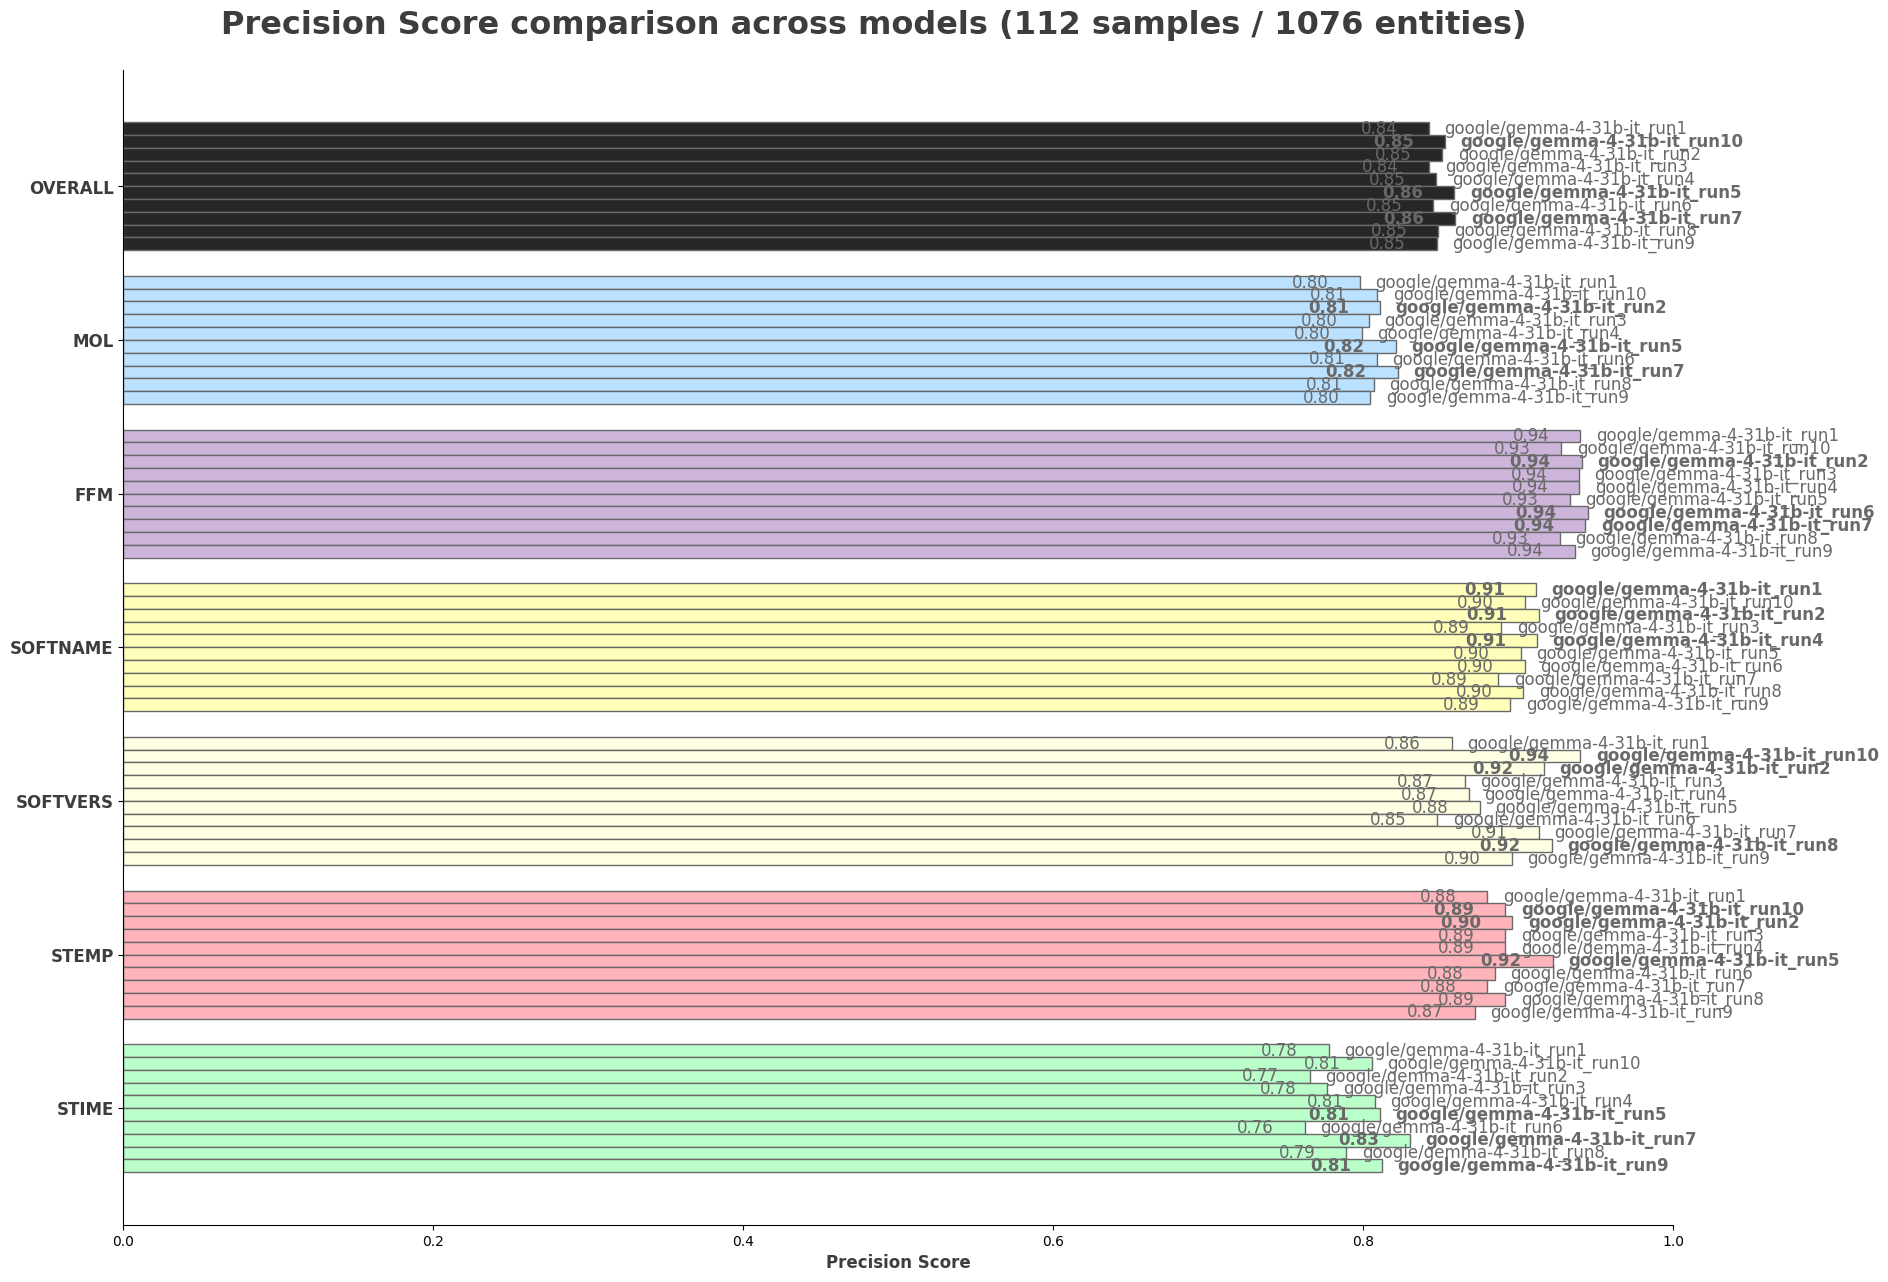

In [89]:
plot_score(
    df=llm_df,
    # Framework to filter ("noframework", "instructor", "pydanticai")
    framework="instructor",
    # Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
    metric="precision_score",
    # Categories to plot in this order
    categories=["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "STEMP", "STIME"],
    # Models to include in the plot (default is all, but you can specify a subset)
    models=model_names.tolist()
)

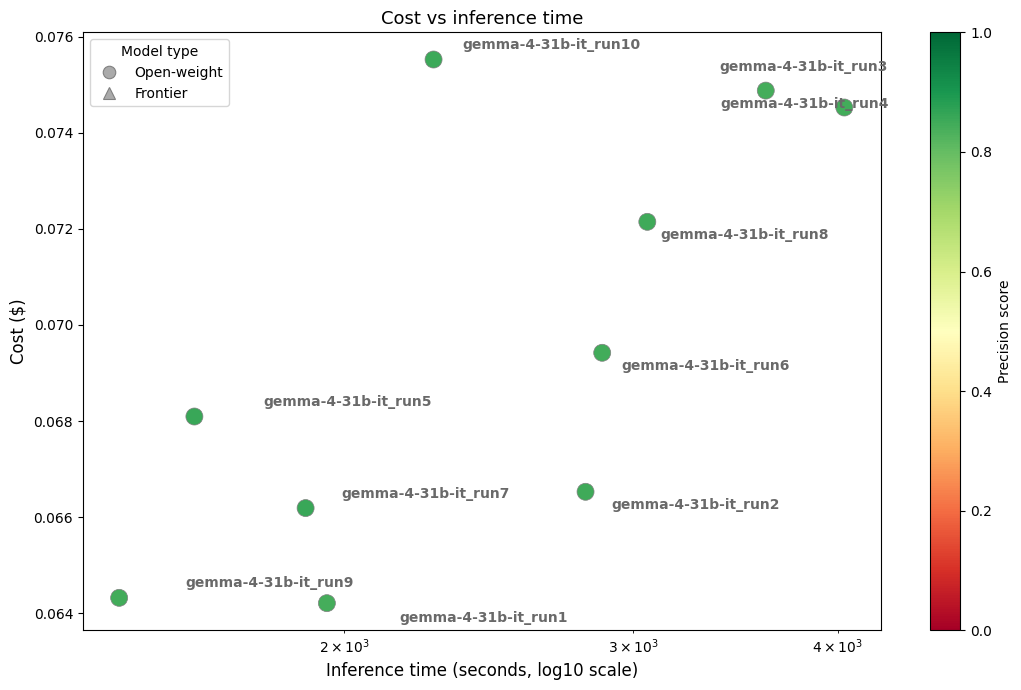

In [90]:
plot_llm_cost_vs_time(llm_df, framework="instructor")

In [91]:
plot_mean_model_performance(
    "../results/llm/evaluation_stats_gemma/grouped_evaluation_metrics.csv",
    "precision_score",
)


In [92]:
plot_mean_model_performance(
    "../results/llm/evaluation_stats_gemma/grouped_evaluation_metrics.csv",
    "f1_score",
)


## **Comparison of GLINER2 Models**

In [ ]:
path = Path("../results/gliner/evaluation_stats/grouped_evaluation_metrics.csv")
gliner_df = pd.read_csv(path)
model_names = gliner_df["model_name"].unique()
category_names = gliner_df["category"].unique()
print(f"Models ({len(model_names)}): {', '.join(model_names)}")
print(f"Categories ({len(category_names)}): {', '.join(category_names)}")
gliner_df

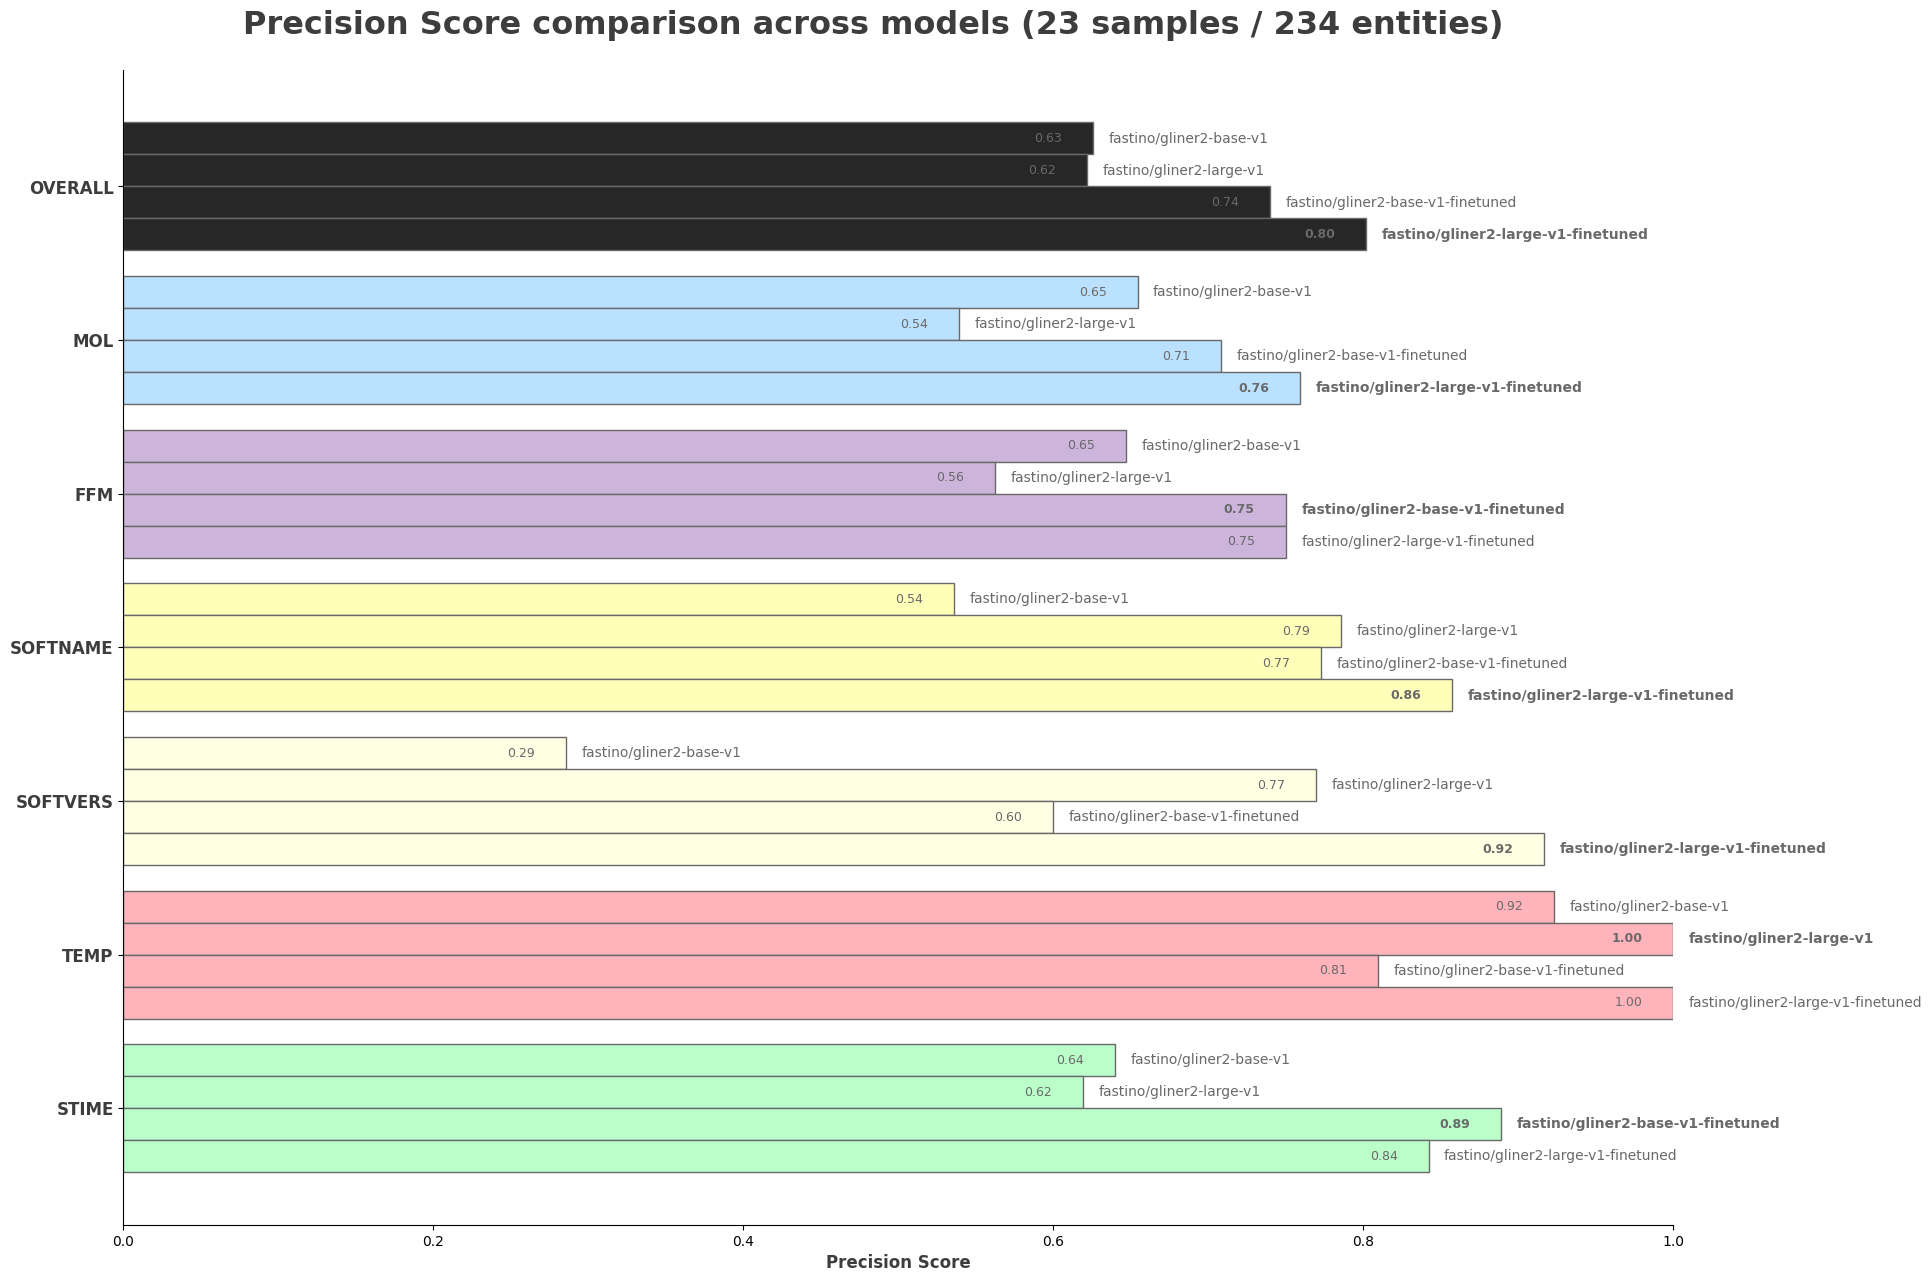

In [ ]:
plot_score(
    df=gliner_df,
    framework="noframework",
    metric="precision_score",
    categories=["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"],
    models=gliner_df["model_name"].unique().tolist(),
    top_k=1,
)

## **Comparison of GLINER2 vs LLM Models**

In [ ]:
# Concat all evaluation results
gliner_df["framework_name"] = None
eval_df = pd.concat([llm_df, gliner_df], ignore_index=True)
eval_df

,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,anthropic/claude-sonnet-4.6,instructor,FFM,83,179,141,100.0,0.0,130,11,49,3771.928571,227.845238,NaN,NaN,0.921986,0.726257,0.812500,0.874832
1,anthropic/claude-sonnet-4.6,instructor,MOL,110,566,519,100.0,0.0,324,195,242,3768.339286,216.428571,NaN,NaN,0.624277,0.572438,0.597235,0.613172
2,anthropic/claude-sonnet-4.6,instructor,SOFTNAME,73,125,106,100.0,0.0,96,10,29,3782.697368,227.407895,NaN,NaN,0.905660,0.768000,0.831169,0.874317
3,anthropic/claude-sonnet-4.6,instructor,SOFTVERS,46,52,40,100.0,0.0,36,4,16,3802.702128,243.893617,NaN,NaN,0.900000,0.692308,0.782609,0.849057
4,anthropic/claude-sonnet-4.6,instructor,STIME,68,98,104,100.0,0.0,84,20,14,3797.318841,241.594203,NaN,NaN,0.807692,0.857143,0.831683,0.817121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,fastino/gliner2-large-v1-finetuned,None,TEMP,13,17,15,100.0,0.0,15,0,2,221.076923,218.615385,NaN,NaN,1.000000,0.882353,0.937500,0.974026
192,fastino/gliner2-base-v1,None,OVERALL,23,234,195,100.0,0.0,122,73,112,261.217391,190.782609,0.0,5.401977,0.625641,0.521368,0.568765,0.601578
193,fastino/gliner2-large-v1,None,OVERALL,23,234,222,100.0,0.0,138,84,96,261.217391,212.260870,0.0,15.629170,0.621622,0.589744,0.605263,0.614973
194,fastino/gliner2-base-v1-finetuned,None,OVERALL,23,211,200,100.0,0.0,148,52,63,230.304348,191.521739,0.0,4.385949,0.740000,0.701422,0.720195,0.731949


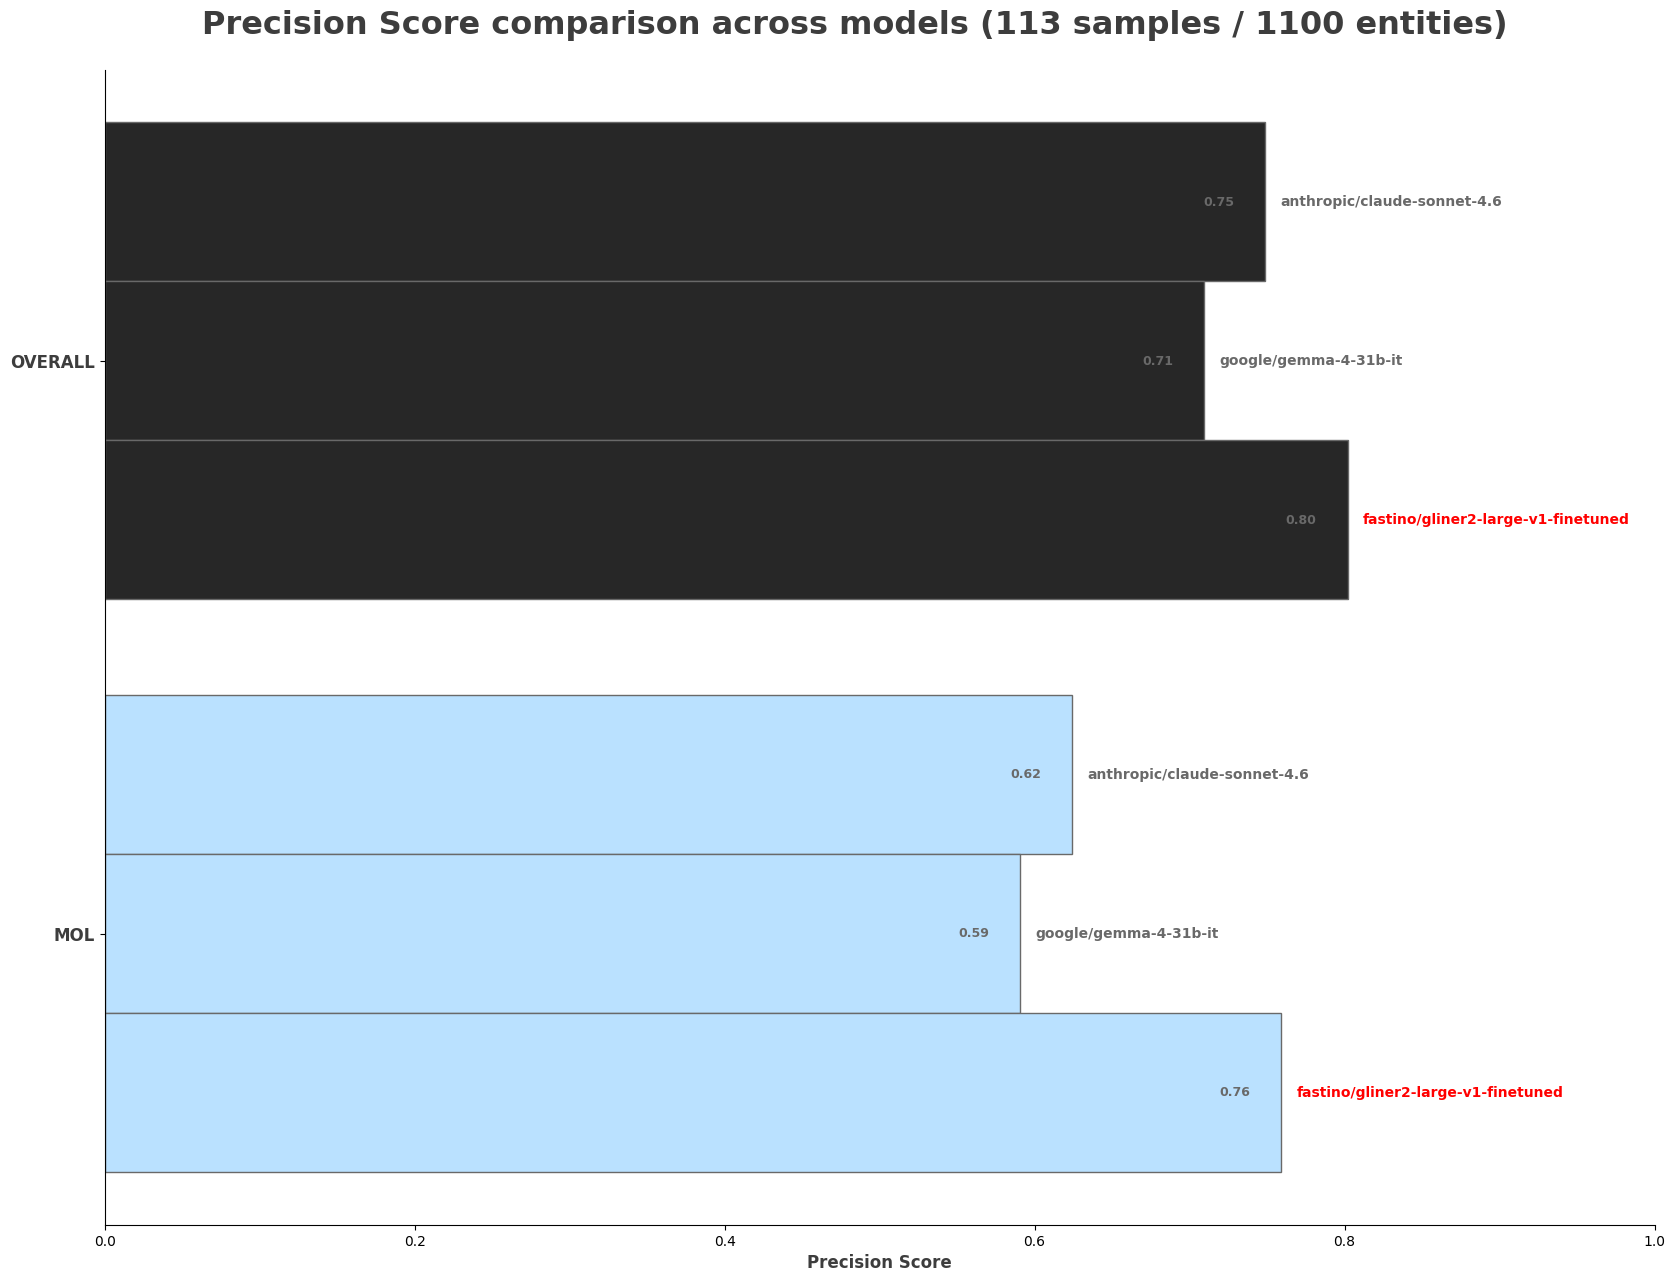

In [ ]:
plot_score(
    df=eval_df,
    framework="instructor",
    metric="precision_score",
    categories=["OVERALL", "MOL"],
    models=[
        "anthropic/claude-sonnet-4.6",
        "google/gemma-4-31b-it",
        "fastino/gliner2-large-v1-finetuned",
    ],
    top_k=3,
)